<a href="https://colab.research.google.com/github/talhasyed993-spec/AI-Internship-Tasks-2/blob/main/Support_Ticket_Tagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


## Auto Tagging Support Tickets Using LLM

--- Objective: ---
Automatically classify customer support tickets into categories
using Large Language Models.

Techniques:
1. Zero-shot prompting
2. Few-shot prompting
3. Fine-tuning


## Install packages

In [ ]:
!pip install transformers

!pip install datasets

!pip install accelerate

!pip install sentencepiece

!pip install torch

!pip install scikit-learn

!pip install matplotlib

!pip install seaborn

!pip install pandas

# imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

from transformers import pipeline

# Uploading the CSV file in colab notebook

In [ ]:
import io
import pandas as pd
from google.colab import files

# Step 1: Prompt the upload dialog box
uploaded = files.upload()



Saving customer_support_tickets.csv to customer_support_tickets.csv


In [ ]:

df = pd.read_csv(io.BytesIO(uploaded["customer_support_tickets.csv"]))

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


# Dataset Information

In [ ]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

,0
Ticket ID,0
Customer Name,0
Customer Email,0
Customer Age,0
Customer Gender,0
Product Purchased,0
Date of Purchase,0
Ticket Type,0
Ticket Subject,0
Ticket Description,0


# Drop Missing Values

In [ ]:
df = df.dropna()

# Count the number of tickets in each category

In [ ]:
ticket_counts = df["Ticket Type"].value_counts()

print(ticket_counts)

Ticket Type
Refund request          596
Technical issue         580
Billing inquiry         544
Product inquiry         533
Cancellation request    516
Name: count, dtype: int64


# Visualization

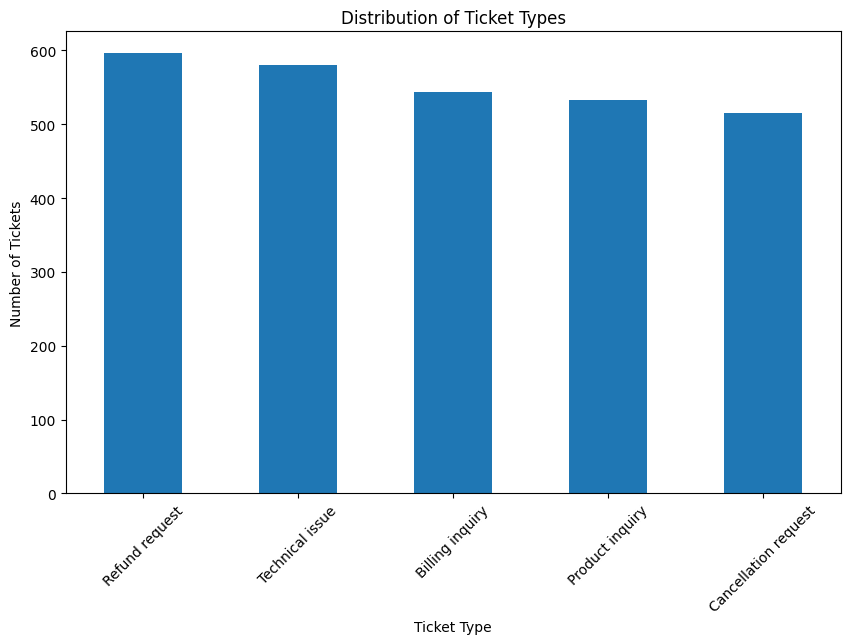

In [ ]:
import matplotlib.pyplot as plt

df["Ticket Type"].value_counts().plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Distribution of Ticket Types")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45)

plt.show()

# Train test split

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Ticket Type"]
)

# Zero short prediction


In [ ]:
example = test_df.iloc[0]["Ticket Description"]

In [ ]:
test_df["Ticket Type"]

,Ticket Type
2449,Cancellation request
3568,Product inquiry
297,Cancellation request
8466,Technical issue
1835,Technical issue
...,...
3680,Technical issue
3140,Product inquiry
7964,Refund request
2535,Cancellation request


In [ ]:
labels = df["Ticket Type"].unique().tolist()

print(labels)

['Technical issue', 'Billing inquiry', 'Cancellation request', 'Product inquiry', 'Refund request']


## The next step is Zero-Shot Classification

In [ ]:
from transformers import pipeline

classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

## Part 2: Few-shot Learning

In this section, we improve the prediction quality by providing the language model with a few labeled examples before asking it to classify a new support ticket.

## classify a ticket:

** Few-shot prompt

In [ ]:
# Example support ticket
example_ticket = test_df.iloc[0]["Ticket Description"]

prompt = f"""
You are an AI assistant that classifies customer support tickets.

Examples:

Ticket:
I forgot my account password and cannot log in.

Tag:
Account access

Ticket:
I was charged twice for my purchase.

Tag:
Billing inquiry

Ticket:
The application crashes every time I open it.

Tag:
Technical issue

Now classify the following ticket.

Ticket:
{example_ticket}

Return the three most appropriate tags.
"""

print(prompt)


You are an AI assistant that classifies customer support tickets.

Examples:

Ticket:
I forgot my account password and cannot log in.

Tag:
Account access

Ticket:
I was charged twice for my purchase.

Tag:
Billing inquiry

Ticket:
The application crashes every time I open it.

Tag:
Technical issue

Now classify the following ticket.

Ticket:
I'm having an issue with the {product_purchased}. Please assist.

Thanks!

-Nora

If you use a different font file, contact me and I will correct it on your desktop. Thank you. I've performed a factory reset on my {product_purchased}, hoping it would resolve the problem, but it didn't help.

Return the three most appropriate tags.



In [ ]:
example = test_df.iloc[0]["Ticket Description"]

result = classifier(
    example,
    labels,
    multi_label=True
)

print(result)

{'sequence': "I'm having an issue with the {product_purchased}. Please assist.\n\nThanks!\n\n-Nora\n\nIf you use a different font file, contact me and I will correct it on your desktop. Thank you. I've performed a factory reset on my {product_purchased}, hoping it would resolve the problem, but it didn't help.", 'labels': ['Product inquiry', 'Technical issue', 'Billing inquiry', 'Refund request', 'Cancellation request'], 'scores': [0.875675618648529, 0.8689676523208618, 0.404296338558197, 0.19848467409610748, 0.062300655990839005]}


## top 3 predicted tags

In [ ]:
print("Ticket:")
print(example)

print("\nTop 3 Predicted Tags:\n")

for label, score in zip(result["labels"][:3], result["scores"][:3]):
    print(f"{label}: {score:.4f}")

Ticket:
I'm having an issue with the {product_purchased}. Please assist.

Thanks!

-Nora

If you use a different font file, contact me and I will correct it on your desktop. Thank you. I've performed a factory reset on my {product_purchased}, hoping it would resolve the problem, but it didn't help.

Top 3 Predicted Tags:

Product inquiry: 0.8757
Technical issue: 0.8690
Billing inquiry: 0.4043


# Fine-Tuning Using DistilBERT

# Fine-Tuning

In this section, we fine-tune a DistilBERT model on the support ticket dataset to classify ticket types. The model learns from labeled examples and is compared with the Zero-shot approach.

# install Required Packeg

In [ ]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


# Import Libraries

In [ ]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import evaluate

In [ ]:
# Keep only the required columns
df = df[["Ticket Description", "Ticket Type"]]

# Remove missing values
df = df.dropna()

df.head()

,Ticket Description,Ticket Type
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry
10,I'm having an issue with the {product_purchase...,Cancellation request
11,I'm having an issue with the {product_purchase...,Product inquiry


# Encode Labels

In [ ]:
label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["Ticket Type"])

print(label_encoder.classes_)

['Billing inquiry' 'Cancellation request' 'Product inquiry'
 'Refund request' 'Technical issue']


# Train/Test Split

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

# Convert to Hugging Face Dataset

In [ ]:
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# Load Tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

# Tokenization Function

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["Ticket Description"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

# Tokenize Dataset

In [ ]:
train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/2215 [00:00<?, ? examples/s]

Map:   0%|          | 0/554 [00:00<?, ? examples/s]

# Remove Unnecessary Columns

In [ ]:
train_dataset = train_dataset.remove_columns(
    ["Ticket Description", "Ticket Type", "__index_level_0__"]
)

test_dataset = test_dataset.remove_columns(
    ["Ticket Description", "Ticket Type", "__index_level_0__"]
)

train_dataset.set_format("torch")
test_dataset.set_format("torch")

# Load Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_encoder.classes_)
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


# Evaluation Metric

In [ ]:
accuracy = evaluate.load("accuracy")

# Compute Metrics

In [ ]:
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    return accuracy.compute(
        predictions=predictions,
        references=labels
    )

# Training Arguments

In [ ]:
training_args = TrainingArguments(
    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_dir="./logs",

    logging_steps=50
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Trainer

In [ ]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

# Again Predicting Top-3 Tags for a Ticket

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import torch

sample = test_df.iloc[0]["Ticket Description"]

inputs = tokenizer(
    sample,
    return_tensors="pt",
    truncation=True,
    padding=True,
    max_length=128
)

with torch.no_grad():
    outputs = model(**inputs)

probs = torch.softmax(outputs.logits, dim=1)

top3 = torch.topk(probs, k=3)

print("Ticket:\n")
print(sample)

print("\nTop 3 Predicted Tags:\n")

for index, score in zip(top3.indices[0], top3.values[0]):
    print(f"{label_encoder.inverse_transform([index.item()])[0]} : {score.item():.4f}")

Ticket:

I'm having an issue with the {product_purchased}. Please assist.

Thanks!

-Nora

If you use a different font file, contact me and I will correct it on your desktop. Thank you. I've performed a factory reset on my {product_purchased}, hoping it would resolve the problem, but it didn't help.

Top 3 Predicted Tags:

Billing inquiry : 0.2482
Refund request : 0.2149
Product inquiry : 0.1832
